# Neural Network from Scratch
Implementation of a neural network framework with activation functions, layers, and training loop

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
from tqdm import tqdm
import json

In [48]:
# setting the seed for reproducibility
np.random.seed(42)

In [49]:
class ReLU:
    """ReLU activation function"""
    def forward(self, x):
        self.input = x
        return np.maximum(0, x)
    
    def backward(self, grad_output):
        return grad_output * (self.input > 0)

class Tanh:
    """Tanh activation function"""
    def forward(self, x):
        self.output = np.tanh(x)
        return self.output
    
    def backward(self, grad_output):
        return grad_output * (1 - self.output ** 2)

class Sigmoid:
    """Sigmoid activation function"""
    def forward(self, x):
        self.output = 1 / (1 + np.exp(-np.clip(x, -500, 500)))
        return self.output
    
    def backward(self, grad_output):
        return grad_output * self.output * (1 - self.output)

class Identity:
    """Identity activation function (no activation)"""
    def forward(self, x):
        return x
    
    def backward(self, grad_output):
        return grad_output

In [50]:
class Linear:
    """Fully connected linear layer with optional activation"""
    def __init__(self, input_width, output_width, activation=None):
        self.input_width = input_width
        self.output_width = output_width
        
        # Initialize weights and biases using He initialization
        self.weights = np.random.randn(input_width, output_width) * np.sqrt(2.0 / input_width)
        self.biases = np.zeros((1, output_width))
        
        # Activation function
        self.activation = activation if activation is not None else Identity()
        
        # Storage for backward pass
        self.input = None
        self.z = None  # Pre-activation output
        self.output = None  # Post-activation output
        
        # Cumulative gradients
        self.grad_weights = np.zeros_like(self.weights)
        self.grad_biases = np.zeros_like(self.biases)
    
    def forward(self, x):
        """Forward pass through the layer"""
        self.input = x
        self.z = np.dot(x, self.weights) + self.biases
        self.output = self.activation.forward(self.z)
        return self.output
    
    def backward(self, grad_output):
        """Backward pass through the layer"""
        # Gradient through activation
        grad_z = self.activation.backward(grad_output)
        
        # Gradients for weights and biases
        batch_size = self.input.shape[0]
        self.grad_weights += np.dot(self.input.T, grad_z)
        self.grad_biases += np.sum(grad_z, axis=0, keepdims=True)
        
        # Gradient to pass to previous layer
        grad_input = np.dot(grad_z, self.weights.T)
        return grad_input
    
    def zero_grad(self):
        """Reset cumulative gradients to zero"""
        self.grad_weights = np.zeros_like(self.weights)
        self.grad_biases = np.zeros_like(self.biases)
    
    def update(self, learning_rate):
        """Update parameters using accumulated gradients"""
        self.weights -= learning_rate * self.grad_weights
        self.biases -= learning_rate * self.grad_biases

In [51]:
class MSELoss:
    """Mean Squared Error loss"""
    def forward(self, y_pred, y_true):
        self.y_pred = y_pred
        self.y_true = y_true
        return np.mean((y_pred - y_true) ** 2)
    
    def backward(self):
        batch_size = self.y_pred.shape[0]
        return 2 * (self.y_pred - self.y_true) / batch_size

class BCELoss:
    """Binary Cross Entropy loss"""
    def forward(self, y_pred, y_true):
        self.y_pred = np.clip(y_pred, 1e-7, 1 - 1e-7)
        self.y_true = y_true
        return -np.mean(y_true * np.log(self.y_pred) + (1 - y_true) * np.log(1 - self.y_pred))
    
    def backward(self):
        batch_size = self.y_pred.shape[0]
        return (self.y_pred - self.y_true) / (self.y_pred * (1 - self.y_pred) * batch_size)

In [52]:
class Model:
    """Neural network model with multiple layers"""
    def __init__(self, layers, loss_type='mse', learning_rate=0.01):
        self.layers = layers
        self.learning_rate = learning_rate
        
        # Initialize loss function
        if loss_type.lower() == 'mse':
            self.loss_fn = MSELoss()
        elif loss_type.lower() == 'bce':
            self.loss_fn = BCELoss()
        else:
            raise ValueError(f"Unknown loss type: {loss_type}")
    
    def forward(self, x):
        """Forward pass through all layers"""
        output = x
        for layer in self.layers:
            output = layer.forward(output)
        return output
    
    def backward(self, grad_output):
        """Backward pass through all layers"""
        grad = grad_output
        for layer in reversed(self.layers):
            grad = layer.backward(grad)
    
    def train(self, x, y):
        """Perform forward pass, compute loss, and backpropagate"""
        # Forward pass
        y_pred = self.forward(x)
        
        # Compute loss
        loss = self.loss_fn.forward(y_pred, y)
        
        # Backward pass
        grad_output = self.loss_fn.backward()
        self.backward(grad_output)
        
        return loss
    
    def zero_grad(self):
        """Reset gradients in all layers"""
        for layer in self.layers:
            layer.zero_grad()
    
    def update(self):
        """Update parameters in all layers and reset gradients"""
        for layer in self.layers:
            layer.update(self.learning_rate)
        self.zero_grad()
    
    def predict(self, x):
        """Make predictions (forward pass without training)"""
        return self.forward(x)
    
    def save_to(self, path):
        """Save model parameters to .npz file"""
        params = {}
        for i, layer in enumerate(self.layers):
            params[f'layer_{i}_weights'] = layer.weights
            params[f'layer_{i}_biases'] = layer.biases
        np.savez(path, **params)
    
    def load_from(self, path):
        """Load model parameters from .npz file"""
        params = np.load(path)
        
        # Verify architecture matches
        for i, layer in enumerate(self.layers):
            weight_key = f'layer_{i}_weights'
            bias_key = f'layer_{i}_biases'
            
            if weight_key not in params or bias_key not in params:
                raise ValueError(f"Missing parameters for layer {i}")
            
            if params[weight_key].shape != layer.weights.shape:
                raise ValueError(f"Weight shape mismatch for layer {i}: "
                               f"expected {layer.weights.shape}, got {params[weight_key].shape}")
            
            if params[bias_key].shape != layer.biases.shape:
                raise ValueError(f"Bias shape mismatch for layer {i}: "
                               f"expected {layer.biases.shape}, got {params[bias_key].shape}")
            
            # Load parameters
            layer.weights = params[weight_key]
            layer.biases = params[bias_key]

In [53]:
def train_model(model, X_train, y_train, 
                batch_size=32, 
                grad_accumulation_steps=1,
                epochs=100,
                early_stopping=True,
                patience=10,
                relative_loss_threshold=0.01,
                run_name=None):
    """
    Training loop with batch processing and gradient accumulation
    
    Args:
        model: Model instance to train
        X_train: Training data
        y_train: Training labels
        batch_size: Number of samples per batch
        grad_accumulation_steps: Number of batches to accumulate gradients over
        epochs: Maximum number of epochs
        early_stopping: Whether to use early stopping
        patience: Number of epochs to check for loss improvement
        relative_loss_threshold: Relative threshold for early stopping
        run_name: Optional name for the run folder
    """
    # Create run directory
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    run_folder = Path(f"runs/{run_name or timestamp}")
    run_folder.mkdir(parents=True, exist_ok=True)
    
    # Training tracking
    losses = []
    samples_seen = []
    epoch_losses = []
    total_samples = 0
    
    n_samples = X_train.shape[0]
    n_batches = int(np.ceil(n_samples / batch_size))
    
    print(f"Training for up to {epochs} epochs...")
    print(f"Batch size: {batch_size}, Grad accumulation steps: {grad_accumulation_steps}")
    print(f"Effective batch size: {batch_size * grad_accumulation_steps}")
    
    for epoch in range(epochs):
        epoch_loss = 0
        
        # Shuffle data
        indices = np.random.permutation(n_samples)
        X_shuffled = X_train[indices]
        y_shuffled = y_train[indices]
        
        # Progress bar for batches
        pbar = tqdm(range(n_batches), desc=f"Epoch {epoch+1}/{epochs}")
        
        for batch_idx in pbar:
            start_idx = batch_idx * batch_size
            end_idx = min(start_idx + batch_size, n_samples)
            
            X_batch = X_shuffled[start_idx:end_idx]
            y_batch = y_shuffled[start_idx:end_idx]
            
            # Train on batch (accumulates gradients)
            loss = model.train(X_batch, y_batch)
            epoch_loss += loss * (end_idx - start_idx)
            total_samples += (end_idx - start_idx)
            
            # Update parameters after accumulation steps
            if (batch_idx + 1) % grad_accumulation_steps == 0 or batch_idx == n_batches - 1:
                model.update()
            
            # Record loss and samples
            losses.append(loss)
            samples_seen.append(total_samples)
            
            pbar.set_postfix({'loss': f'{loss:.6f}'})
        
        # Calculate average epoch loss
        avg_epoch_loss = epoch_loss / n_samples
        epoch_losses.append(avg_epoch_loss)
        
        print(f"Epoch {epoch+1}/{epochs} - Average Loss: {avg_epoch_loss:.6f}")
        
        # Early stopping check
        if early_stopping and epoch >= patience:
            # FIX: Add this line back to define current_loss
            current_loss = epoch_losses[-1]
            past_loss = epoch_losses[-patience-1]
            
            # Stop if the current loss is not better (lower) than the past loss 
            # by at least the relative threshold.
            if current_loss > past_loss * (1 - relative_loss_threshold):
                print(f"\nEarly stopping triggered at epoch {epoch+1}.")
                print(f"Loss did not improve by at least {relative_loss_threshold*100:.2f}% over the last {patience} epochs.")
                break

    
    # Save training results
    print(f"\nSaving results to {run_folder}")
    
    # Plot training loss
    plt.figure(figsize=(10, 6))
    plt.plot(samples_seen, losses, alpha=0.6, label='Batch Loss')
    plt.xlabel('Samples Seen')
    plt.ylabel('Loss')
    plt.title('Training Loss vs Samples Seen')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(run_folder / 'training_loss.png', dpi=300, bbox_inches='tight')
    plt.close()
    
    # Plot epoch losses
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(epoch_losses)+1), epoch_losses, marker='o')
    plt.xlabel('Epoch')
    plt.ylabel('Average Loss')
    plt.title('Average Epoch Loss')
    plt.grid(True, alpha=0.3)
    plt.savefig(run_folder / 'epoch_loss.png', dpi=300, bbox_inches='tight')
    plt.close()
    
    # Save model
    model.save_to(run_folder / 'model.npz')
    
    # Save hyperparameters and results
    results = {
        'hyperparameters': {
            'batch_size': batch_size,
            'grad_accumulation_steps': grad_accumulation_steps,
            'learning_rate': model.learning_rate,
            'epochs_trained': len(epoch_losses),
            'early_stopping': early_stopping,
            'patience': patience,
            'relative_loss_threshold': relative_loss_threshold
        },
        'final_loss': float(epoch_losses[-1]),
        'min_loss': float(min(epoch_losses)),
        'total_samples_seen': int(total_samples)
    }
    
    with open(run_folder / 'results.json', 'w') as f:
        json.dump(results, f, indent=2)
    
    print(f"Training complete! Results saved to {run_folder}")
    
    return losses, samples_seen, epoch_losses, run_folder

In [54]:
# Generate XOR dataset
np.random.seed(42)
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=np.float32)
y_xor = np.array([[0], [1], [1], [0]], dtype=np.float32)

# Repeat the dataset to have more samples
X_train = np.tile(X_xor, (250, 1))
y_train = np.tile(y_xor, (250, 1))

# Add some noise
X_train += np.random.randn(*X_train.shape) * 0.01

print(f"Training data shape: {X_train.shape}")
print(f"Training labels shape: {y_train.shape}")

Training data shape: (1000, 2)
Training labels shape: (1000, 1)


In [55]:
# Cell 8: Create and Train Model
# Create model
layers = [
    Linear(2, 8, activation=ReLU()),
    Linear(8, 8, activation=ReLU()),
    Linear(8, 1, activation=Sigmoid())
]

model = Model(layers, loss_type='bce', learning_rate=0.1)

# Train model
losses, samples_seen, epoch_losses, run_folder = train_model(
    model=model,
    X_train=X_train,
    y_train=y_train,
    batch_size=32,
    grad_accumulation_steps=2,
    epochs=100,
    early_stopping=True,
    patience=10,
    relative_loss_threshold=0.01,
    run_name='xor_experiment'
)

Training for up to 100 epochs...
Batch size: 32, Grad accumulation steps: 2
Effective batch size: 64


Epoch 1/100: 100%|██████████| 32/32 [00:00<00:00, 2040.25it/s, loss=0.454268]


Epoch 1/100 - Average Loss: 0.595707


Epoch 2/100: 100%|██████████| 32/32 [00:00<00:00, 2060.86it/s, loss=0.364051]


Epoch 2/100 - Average Loss: 0.400037


...

Epoch 98/100 - Average Loss: 0.000411


Epoch 99/100: 100%|██████████| 32/32 [00:00<00:00, 2806.14it/s, loss=0.000353]


Epoch 99/100 - Average Loss: 0.000405


Epoch 100/100: 100%|██████████| 32/32 [00:00<00:00, 2775.79it/s, loss=0.000417]


Epoch 100/100 - Average Loss: 0.000400

Saving results to runs/xor_experiment
Training complete! Results saved to runs/xor_experiment


In [56]:
# Cell 9: Test Model
# Test on original XOR inputs
print("\nTesting on XOR inputs:")
for i, (x, y) in enumerate(zip(X_xor, y_xor)):
    pred = model.predict(x.reshape(1, -1))
    print(f"Input: {x}, True: {y[0]:.0f}, Predicted: {pred[0][0]:.4f}")


Testing on XOR inputs:
Input: [0. 0.], True: 0, Predicted: 0.0002
Input: [0. 1.], True: 1, Predicted: 0.9997
Input: [1. 0.], True: 1, Predicted: 0.9993
Input: [1. 1.], True: 0, Predicted: 0.0003


In [57]:
# Cell 10: Load Saved Model (Example)
# Create a new model with same architecture
new_model = Model([
    Linear(2, 8, activation=ReLU()),
    Linear(8, 8, activation=ReLU()),
    Linear(8, 1, activation=Sigmoid())
], loss_type='bce', learning_rate=0.1)

# Load saved parameters
new_model.load_from(run_folder / 'model.npz')

print("\nTesting loaded model on XOR inputs:")
for i, (x, y) in enumerate(zip(X_xor, y_xor)):
    pred = new_model.predict(x.reshape(1, -1))
    print(f"Input: {x}, True: {y[0]:.0f}, Predicted: {pred[0][0]:.4f}")


Testing loaded model on XOR inputs:
Input: [0. 0.], True: 0, Predicted: 0.0002
Input: [0. 1.], True: 1, Predicted: 0.9997
Input: [1. 0.], True: 1, Predicted: 0.9993
Input: [1. 1.], True: 0, Predicted: 0.0003


## Image Border Classification Task
Training a neural network to learn the border pattern from an image

Image shape: (50, 50)
Total pixels: 2500
Sample data point: ((42, 36), np.uint8(1))


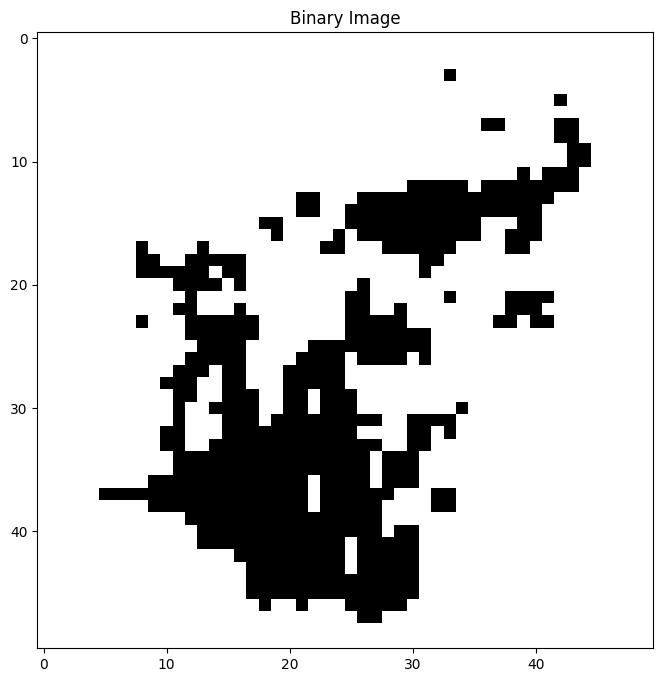

In [58]:
# Cell 11: Load and Prepare Image Dataset
import cv2 as cv

# Loading the image
img = cv.imread("dataset/Q1/border.png", cv.IMREAD_GRAYSCALE)
# Masking the image as binary
_, binary = cv.threshold(img, 127, 255, cv.THRESH_BINARY)
binary = binary // 255

class DataSetClass:
    def __init__(self, img):
        self.img = img
    
    # Returning ((x,y), L) of the shuffled dataset
    def getDataset(self):
        dataset = []
        for i in range(self.img.shape[0]):
            for j in range(self.img.shape[1]):
                dataset.append(((i, j), self.img[i][j]))
        np.random.shuffle(dataset)
        return dataset

# Create dataset
data = DataSetClass(binary)
dataset = data.getDataset()

print(f"Image shape: {binary.shape}")
print(f"Total pixels: {len(dataset)}")
print(f"Sample data point: {dataset[0]}")

# Visualize the binary image
plt.figure(figsize=(8, 8))
plt.imshow(binary, cmap='gray')
plt.title('Binary Image')
plt.show()

In [59]:

height, width = binary.shape

X_image = np.array([coord for coord, label in dataset], dtype=np.float32)
y_image = np.array([[label] for coord, label in dataset], dtype=np.float32)

# Normalize coordinates
X_image[:, 0] = X_image[:, 0] / (height - 1)  # Normalize row (y-coordinate)
X_image[:, 1] = X_image[:, 1] / (width - 1)   # Normalize column (x-coordinate)

print(f"Training data shape: {X_image.shape}")
print(f"Training labels shape: {y_image.shape}")
print(f"X range: [{X_image.min():.3f}, {X_image.max():.3f}]")
print(f"Y unique values: {np.unique(y_image)}")
print(f"Class distribution: 0={np.sum(y_image==0)}, 1={np.sum(y_image==1)}")

Training data shape: (2500, 2)
Training labels shape: (2500, 1)
X range: [0.000, 1.000]
Y unique values: [0. 1.]
Class distribution: 0=514, 1=1986


In [ ]:
# Cell 13: Create and Train Model for Image Classification
# Create model with deeper architecture for complex pattern
layers_image = [
    Linear(2, 8, activation=Tanh()),
     Linear(8, 8, activation=Tanh()),
    # Linear(64, 32, activation=Tanh()),
    Linear(8, 1, activation=Sigmoid())
]

model_image = Model(layers_image, loss_type='bce', learning_rate=0.01)

# Train model
losses_img, samples_seen_img, epoch_losses_img, run_folder_img = train_model(
    model=model_image,
    X_train=X_image,
    y_train=y_image,
    batch_size=16,
    grad_accumulation_steps=4,
    epochs=5000,
    early_stopping=False,
    patience=20,
    relative_loss_threshold=0.001,
    run_name='border_classification/10'
)

Training for up to 5000 epochs...
Batch size: 16, Grad accumulation steps: 4
Effective batch size: 64


Epoch 1/5000: 100%|██████████| 157/157 [00:00<00:00, 2802.69it/s, loss=0.576446]


Epoch 1/5000 - Average Loss: 0.527493


Epoch 2/5000: 100%|██████████| 157/157 [00:00<00:00, 2411.45it/s, loss=0.528124]


Epoch 2/5000 - Average Loss: 0.516820


...

Epoch 4702/5000: 100%|██████████| 157/157 [00:00<00:00, 2414.23it/s, loss=0.410741]


Epoch 4702/5000 - Average Loss: 0.184886


Epoch 4703/5000: 100%|██████████| 157/157 [00:00<00:00, 2798.62it/s, loss=0.017275]


Epoch 4703/5000 - Average Loss: 0.185659


Epoch 4704/5000:   0%|          | 0/157 [00:00<?, ?it/s, loss=0.137919]

In [ ]:
# Cell 14: Evaluate and Visualize Results
# Generate predictions for all pixels
predictions = model_image.predict(X_image)
predicted_binary = (predictions > 0.5).astype(np.float32)

# Reshape predictions back to image shape
# Create coordinate grid
y_coords, x_coords = np.meshgrid(np.arange(height), np.arange(width), indexing='ij')
coords_grid = np.stack([y_coords.flatten() / (height - 1), 
                        x_coords.flatten() / (width - 1)], axis=1).astype(np.float32)

# Get predictions for ordered grid
pred_grid = model_image.predict(coords_grid)
pred_image = pred_grid.reshape(height, width)
pred_binary_image = (pred_image > 0.5).astype(np.float32)

# Calculate accuracy
accuracy = np.mean(pred_binary_image == binary) * 100
print(f"\nAccuracy: {accuracy:.2f}%")

# Visualize results
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

# Original image
axes[0, 0].imshow(binary, cmap='gray')
axes[0, 0].set_title('Original Binary Image')
axes[0, 0].axis('off')

# Predicted probabilities
im1 = axes[0, 1].imshow(pred_image, cmap='gray', vmin=0, vmax=1)
axes[0, 1].set_title('Predicted Probabilities')
axes[0, 1].axis('off')
plt.colorbar(im1, ax=axes[0, 1])

# Predicted binary
axes[1, 0].imshow(pred_binary_image, cmap='gray')
axes[1, 0].set_title(f'Predicted Binary (Acc: {accuracy:.2f}%)')
axes[1, 0].axis('off')

# Difference map
diff = np.abs(binary - pred_binary_image)
im3 = axes[1, 1].imshow(diff, cmap='Reds')
axes[1, 1].set_title(f'Errors (Red pixels: {np.sum(diff):.0f})')
axes[1, 1].axis('off')
plt.colorbar(im3, ax=axes[1, 1])

plt.tight_layout()
plt.savefig(run_folder_img / 'prediction_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nResults saved to: {run_folder_img}")

In [ ]:
# Cell 15: Test on Specific Coordinates
# Test on some specific coordinates
test_coords = np.array([
    [0, 0],      # Top-left corner
    [0, width-1],    # Top-right corner
    [height-1, 0],   # Bottom-left corner
    [height-1, width-1],  # Bottom-right corner
    [height//2, width//2]  # Center
], dtype=np.float32)

# Normalize test coordinates
test_coords_norm = test_coords.copy()
test_coords_norm[:, 0] = test_coords_norm[:, 0] / (height - 1)
test_coords_norm[:, 1] = test_coords_norm[:, 1] / (width - 1)

print("\nTesting specific coordinates:")
for coord, coord_norm in zip(test_coords, test_coords_norm):
    pred = model_image.predict(coord_norm.reshape(1, -1))
    true_val = binary[int(coord[0]), int(coord[1])]
    print(f"Coord ({int(coord[0]):3d}, {int(coord[1]):3d}): True={true_val}, Predicted={pred[0][0]:.4f} -> {int(pred[0][0] > 0.5)}")